In [1]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import h5py

import os
import sys
sys.path.append(os.path.abspath("./"))

print(os.getpid())
%cd ../../

import pylib.mix as mix
import carleman as ca
from matplotlib import colors
plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

73524
c:\Users\ivan9\Documents\work\codes\QuCF\scripts-py


In [2]:
path_save_ = "./jupyter-notebooks/Carleman/results/"
for i in range(100):
    plt.close()

colors_     = ["blue", "red", "green", "gray", "black"]
linestyles_ = ["-", "--", "--", ":"]


System coefficients:
mu = 0.200
xi_x = 0.000
xi_y = 0.000

Nt: 2048
init. cond.:   0.20   0.00 




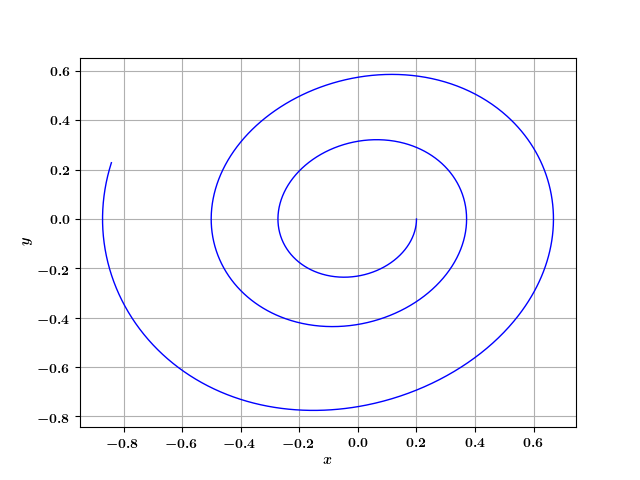

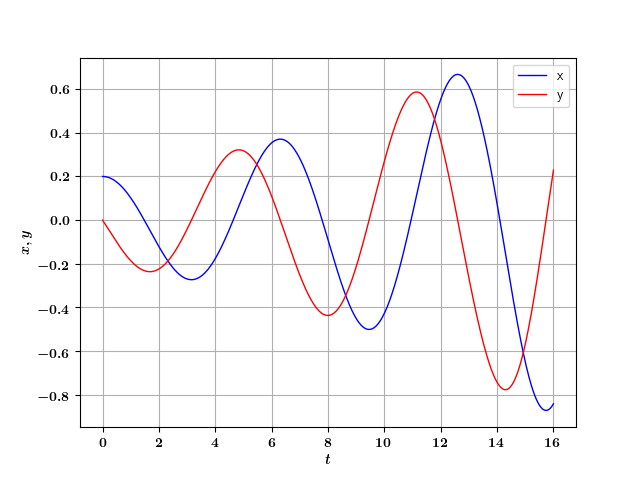

2049


In [9]:
# ---------------------------------------------------------------
# --- Prepare the system ---
# ---------------------------------------------------------------
mix.reload_module(ca)
mix.reload_module(mix)
def choose_case(N_nl, sel_case):
    Nx = 2  # the number of degrees of freedom
    Nx2 = Nx**2 - 1
    Nx3 = Nx**3 - 1

    F_terms = [None] * (N_nl + 1)
    for ii_nl in range(N_nl + 1):
        F_terms[ii_nl] = np.zeros((Nx,int(Nx**ii_nl)))

    # ----------------------------------------------------
    # --- Harmonic oscillator ---
    if sel_case == 0:
        x_init = np.array([0.5, 0.5])

        tmax, nt = 10, 8

        # m, w, xc = 1., 1., 0.4  # reference
        # m, w, xc = 1., 1., 0.6  # still works
        # m, w, xc = 1., 1., 10.  # still works
        m, w, xc = 4., 1., 0.  # still works

        a, b = 1./m, -m*w**2
        c = b * xc
        F = [
            lambda x: a * x[1],
            lambda x: b * x[0] - c
        ]
        # tentative initial conditions: [0.5, 0.5]

        # --- Construct system matrices ---
        # *** matrix F) ***
        F_terms[0][1,0] = - c

        # *** matrix F1 ***
        F_terms[1][0,1], F_terms[1][1,0] = a, b

    # ----------------------------------------------------
    # --- Flying away trajectory ---
    if sel_case == 1:
        x_init = np.array([0.2, 0.0])

        tmax, nt = 10, 8
        F = [
            lambda x: -x[1] - x[0]**2,
            lambda x: -x[0] + x[1]**2,
        ]
        # tentative initial conditions: [1.0, 0.0]

        # --- Construct system matrices ---
        # *** matrix F1 ***
        F_terms[1][0,1], F_terms[1][1,0] = -1, -1

        # *** matrix F2 ***
        F_terms[2][0,0], F_terms[2][1,Nx2] = -1, +1

    # ----------------------------------------------------
    # --- Flying away trajectory ---
    if sel_case == 11:
        # x_init = np.array([0.6, 0.0])
        x_init = np.array([0.2, 0.0])

        tmax, nt = 3, 8
        F = [
            lambda x: -x[1] - x[0]**2,
            lambda x: -x[0] + x[1]**2,
        ]
        # tentative initial conditions: [1.0, 0.0]

        # --- Construct system matrices ---
        # *** matrix F0 ***
        F_terms[0][0,0], F_terms[0][1,0] = -0.2, 0.0

        # *** matrix F1 ***
        F_terms[1][0,1], F_terms[1][1,0] = -1, -1

        # *** matrix F2 ***
        F_terms[2][0,0], F_terms[2][1,Nx2] = -1, +1
        
    # ----------------------------------------------------
    # --- Van der Pol oscillator (limit cycle) ---
    if sel_case == 2:
        x_init = np.array([0.2, 0.0])

        # tmax, nt = 80, 11
        # tmax, nt = 20, 11
        tmax, nt = 16, 11

        # mu  = 0.1  # the reference case
        # mu  = 0.4  # one see the instability
        # mu  = 0.2  # see how the error grows
        mu  = 0.3  # one can clearly see the instability (for N_nl = 4)
        F = [
            lambda x: x[1],
            lambda x: mu * (1 - x[0]**2) * x[1] - x[0],
        ]

        # tentative initial conditions: [0.2, 0.0]

        # --- Construct system matrices ---
        eta = 1.
        a1 = mu 
        a2 = - mu

        # *** matrix F1 ***
        F_terms[1][0,1] = eta
        F_terms[1][1,0] = -eta
        F_terms[1][1,1] = a1

        # *** matrix F3 ***
        F_terms[3][1,1] = a2

    # ----------------------------------------------------
    # --- Van der Pol oscillator (limit cycle, for globalization) ---
    if sel_case == 20:
        x_init = np.array([0.2, 0.0])
        tmax, nt = 16, 11

        # mu, xi_x, xi_y  = 0.3, 0.0, 0.0  # one can clearly see the instability (for N_nl = 4)
        mu, xi_x, xi_y  = 0.2, 0.0, 0.0  # one can clearly see the instability (for N_nl = 4)

        x_init -= np.array([xi_x, xi_y])

        sys_coefs = {}
        sys_coefs["mu"]   = mu
        sys_coefs["xi_x"] = xi_x
        sys_coefs["xi_y"] = xi_y

        def return_sys(ss):
            mu   = ss["mu"]
            xi_x = ss["xi_x"]
            xi_y = ss["xi_y"]
            F_terms = [None] * (N_nl + 1)
            for ii_nl in range(N_nl + 1):
                F_terms[ii_nl] = np.zeros((Nx,int(Nx**ii_nl)))
            
            F_terms[0][0,0] = xi_y
            F_terms[0][1,0] = - xi_x + mu * xi_y - mu * xi_x**2 * xi_y

            F_terms[1][0, 1] = 1.
            F_terms[1][1, 0] = - (1 + 2. * mu * xi_x * xi_y)
            F_terms[1][1, 1] = mu * (1. - xi_x**2)

            F_terms[2][1, 0] = - mu * xi_y
            F_terms[2][1, 1] = - 2. * xi_x * mu

            F_terms[3][1, 1] = - mu
            return F_terms
        
        def shift_coefs(ss, zeta):
            ss_new = dict(ss)
            ss_new["xi_x"] = ss_new["xi_x"] + zeta[0]
            ss_new["xi_y"] = ss_new["xi_y"] + zeta[1]
            if "xi_z" in ss_new:
                ss_new["xi_z"] = ss_new["xi_z"] + zeta[2]
            return ss_new
        
        print("\nSystem coefficients:")
        for key, value in sys_coefs.items():
            print("{:s} = {:0.3f}".format(key, value))
        print()

        F_terms = return_sys(sys_coefs)
        F = [
            lambda x: F_terms[0][0,0] + F_terms[1][0, 1] * x[1],
            lambda x: F_terms[0][1,0] 
                + F_terms[1][1, 0] * x[0]    + F_terms[1][1, 1] * x[1] 
                + F_terms[2][1, 0] * x[0]**2 + F_terms[2][1, 1] * x[0] * x[1] 
                + F_terms[3][1, 1] * x[0]**2 * x[1]
        ]
    # ----------------------------------------------------

    return F, tmax, nt, Nx, x_init, sys_coefs, return_sys, shift_coefs
# ------------------------------------------------------------------------------
sel_case_ = 20

N_nl_orig_ = 3 # formally assume that all considered equations are of the 3-rd order of nonlinearity
F_, tmax_, nt_, Nx_, x_init_ref_, sys_coefs_, return_sys_, shift_coefs_ = choose_case(N_nl_orig_, sel_case = sel_case_)
Nt_ = 1 << nt_
t_ = np.linspace(0, tmax_, Nt_)
dt_ = np.diff(t_)[0]

print("Nt: {:d}".format(Nt_))
print("init. cond.: ", end = "")
mix.print_array(x_init_ref_, ff = [6, 2, "f"])

# --- Standard method (for reference) ---
sol_ref_, t_ref_ = ca.analyse_classical(x_init_ref_, t_, F_)

print(len(t_ref_))

In [14]:
# --------------------------------------------------------------------
# --- Carleman linearization ---
# --------------------------------------------------------------------
mix.reload_module(ca)
N_nl = 8   # should be >= N_nl_orig_

# sol_emb_, t_emb_ = ca.solve_carleman_orig(x_init_ref_, N_nl, N_nl_orig_, t_, return_sys_(sys_coefs_))

sol_emb_, t_emb_ = ca.solve_carleman_global(
    x_init_ref_, N_nl, N_nl_orig_, t_, 
    sys_coefs_, return_sys_, shift_coefs_,
    zeta_th = 0.8
)


The total number of variables in the embedding: 510
--- Shift to another chart, t = 14.359 ---
radius: 0.8
zeta_gl:  -0.20  -0.78 
xs:     -2.004e-01     -7.753e-01 

--- Shift to another chart, t = 14.366 ---
radius: 0.8
zeta_gl:  -0.00  -0.00 
xs:      1.998e-01      7.752e-01 

Done


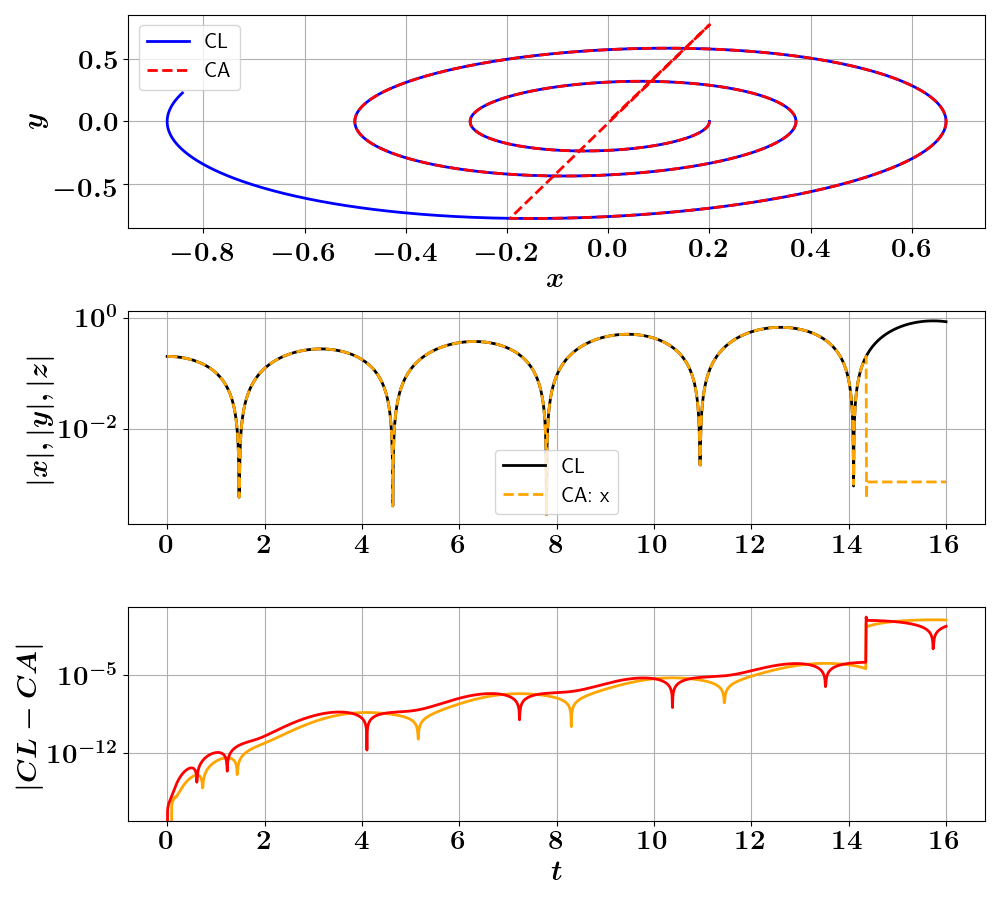

In [15]:
# --------------------------------------------------------------------
# --- Compare trajectories ---
# --------------------------------------------------------------------
mix.reload_module(ca)
ca.compare_trajectory_cl_and_carleman(t_ref_, sol_ref_, t_emb_, sol_emb_)